# Proyecto Final ML — Clasificación de Calidad de Café (CQI)
**Curso:** Machine Learning  
**Dataset:** Coffee Quality Institute (CQI) — Arabica  
**Objetivo:** Clasificar muestras de café como *Specialty* (≥80 puntos) o *No Specialty* (<80 puntos)

---

## 0. Descripción del Proyecto

### Problema de interés
La evaluación de calidad del café es un proceso crítico en la industria cafetera. Actualmente la realizan catadores certificados (Q-Graders) siguiendo los protocolos del **Coffee Quality Institute (CQI)**, asignando puntajes a atributos sensoriales como aroma, sabor, acidez y cuerpo. Este proceso es subjetivo, costoso y difícil de escalar.

### Objetivo del modelo
Clasificar muestras de café Arábica como:
- **Specialty** → Total Cup Points ≥ 80 (clase 1)
- **No Specialty** → Total Cup Points < 80 (clase 0)

usando sus atributos sensoriales y variables de producción como predictores.

### Tipo de modelo
**Machine Learning Supervisado — Clasificación binaria**

### Dataset
**Coffee Quality Institute (CQI)** — 1,200 muestras de café Arábica con 17 variables (sensoriales + producción).  
Fuente original: https://www.kaggle.com/datasets/volpatto/coffee-quality-database-from-cqi

### Metodología propuesta
1. Exploración y análisis descriptivo (EDA)
2. Preprocesamiento: imputación de nulos, codificación de categóricas, escalado
3. Entrenamiento de 3 modelos: Regresión Logística, Random Forest, XGBoost
4. Optimización de hiperparámetros con GridSearchCV (5-fold estratificado)
5. Evaluación con métricas apropiadas para datos desbalanceados: **F1-Score y AUC-ROC**
6. Análisis de importancia de variables


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay, f1_score, accuracy_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Estilo general
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#4e8c3f', '#c0392b']  # Verde café / Rojo
sns.set_style("whitegrid")

## 1. Carga y Exploración de Datos (EDA)

In [21]:
# =============================================================================
print("=" * 60)
print("1. CARGA Y EXPLORACIÓN DE DATOS")
print("=" * 60)

df = pd.read_csv('coffee_quality.csv')

print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
print(df.head(3).to_string())
print(f"\nTipos de datos y nulos:")
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info[info['Nulos'] > 0])
print(f"\nEstadísticas descriptivas (variables numéricas):")
print(df.describe().round(2).to_string())

# Variable objetivo: Specialty vs No Specialty
df['Quality'] = (df['Total_Cup_Points'] >= 80).astype(int)
df['Quality_Label'] = df['Quality'].map({1: 'Specialty (≥80)', 0: 'No Specialty (<80)'})

print(f"\nDistribución de clases:")
print(df['Quality_Label'].value_counts())
print(f"Proporción: {df['Quality'].mean():.1%} specialty")

1. CARGA Y EXPLORACIÓN DE DATOS

Dimensiones: 1200 filas × 20 columnas

Primeras filas:
   Species Country_of_Origin   Variety Processing_Method         Color  Altitude_mean_meters  Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Uniformity  Clean_Cup  Sweetness  Cupper_Points  Total_Cup_Points  Moisture  Category_One_Defects  Category_Two_Defects
0  Arabica          Colombia  Castillo      Washed / Wet         Green                1365.0   7.80    7.55        7.11     7.17  7.68     7.05        9.74       9.85       9.36           8.07             81.81     11.21                     0                     1
1  Arabica            Brazil    Typica      Washed / Wet  Bluish-Green                1836.0   7.54    7.33        7.47     7.21  7.48     7.25        9.72      10.00      10.00           7.35             81.40      9.86                     0                     1
2  Arabica             Kenya   Bourbon      Washed / Wet         Green                2065.0   7.86    7.55        7.

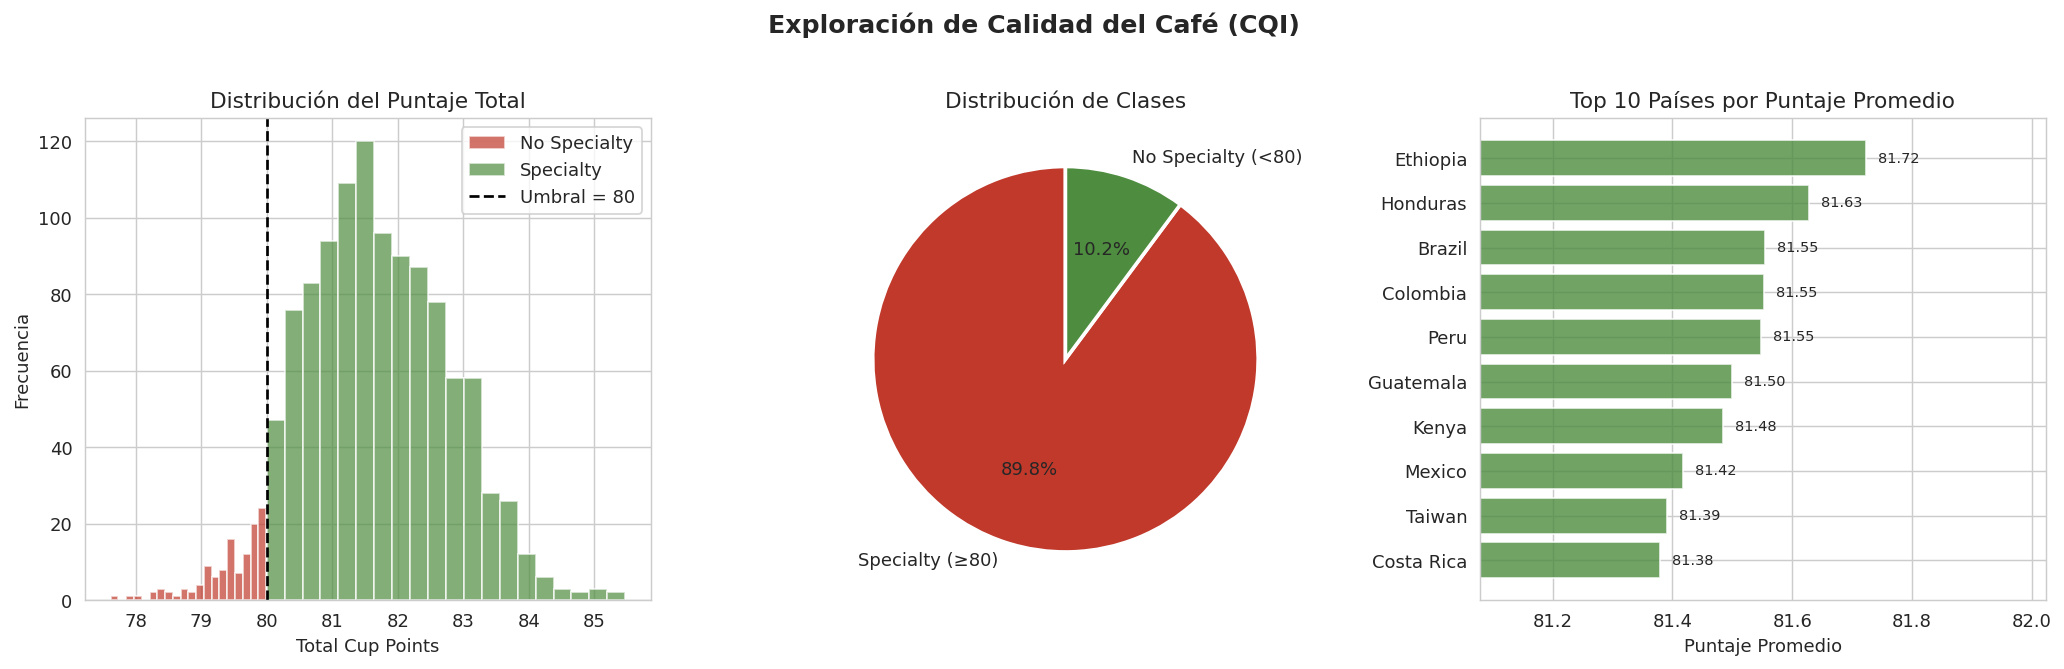

In [22]:
# ---------- FIGURA 1: Distribución del puntaje y clases ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploración de Calidad del Café (CQI)', fontsize=14, fontweight='bold', y=1.02)

# Histograma de puntaje total
ax = axes[0]
ax.hist(df[df['Quality'] == 0]['Total_Cup_Points'], bins=20, color=PALETTE[1],
        alpha=0.7, label='No Specialty', edgecolor='white')
ax.hist(df[df['Quality'] == 1]['Total_Cup_Points'], bins=20, color=PALETTE[0],
        alpha=0.7, label='Specialty', edgecolor='white')
ax.axvline(80, color='black', linestyle='--', lw=1.5, label='Umbral = 80')
ax.set_xlabel('Total Cup Points')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Puntaje Total')
ax.legend()

# Pie chart de clases
ax = axes[1]
counts = df['Quality_Label'].value_counts()
ax.pie(counts, labels=counts.index, colors=PALETTE[::-1],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Distribución de Clases')

# Puntaje promedio por país
ax = axes[2]
country_avg = (df.groupby('Country_of_Origin')['Total_Cup_Points']
               .mean().sort_values(ascending=True).tail(10))
bars = ax.barh(country_avg.index, country_avg.values, color='#4e8c3f', alpha=0.8, edgecolor='white')
ax.set_xlabel('Puntaje Promedio')
ax.set_title('Top 10 Países por Puntaje Promedio')
ax.set_xlim(country_avg.min() - 0.3, country_avg.max() + 0.3)
for bar, val in zip(bars, country_avg.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig1_distribucion.png', bbox_inches='tight')
plt.show()

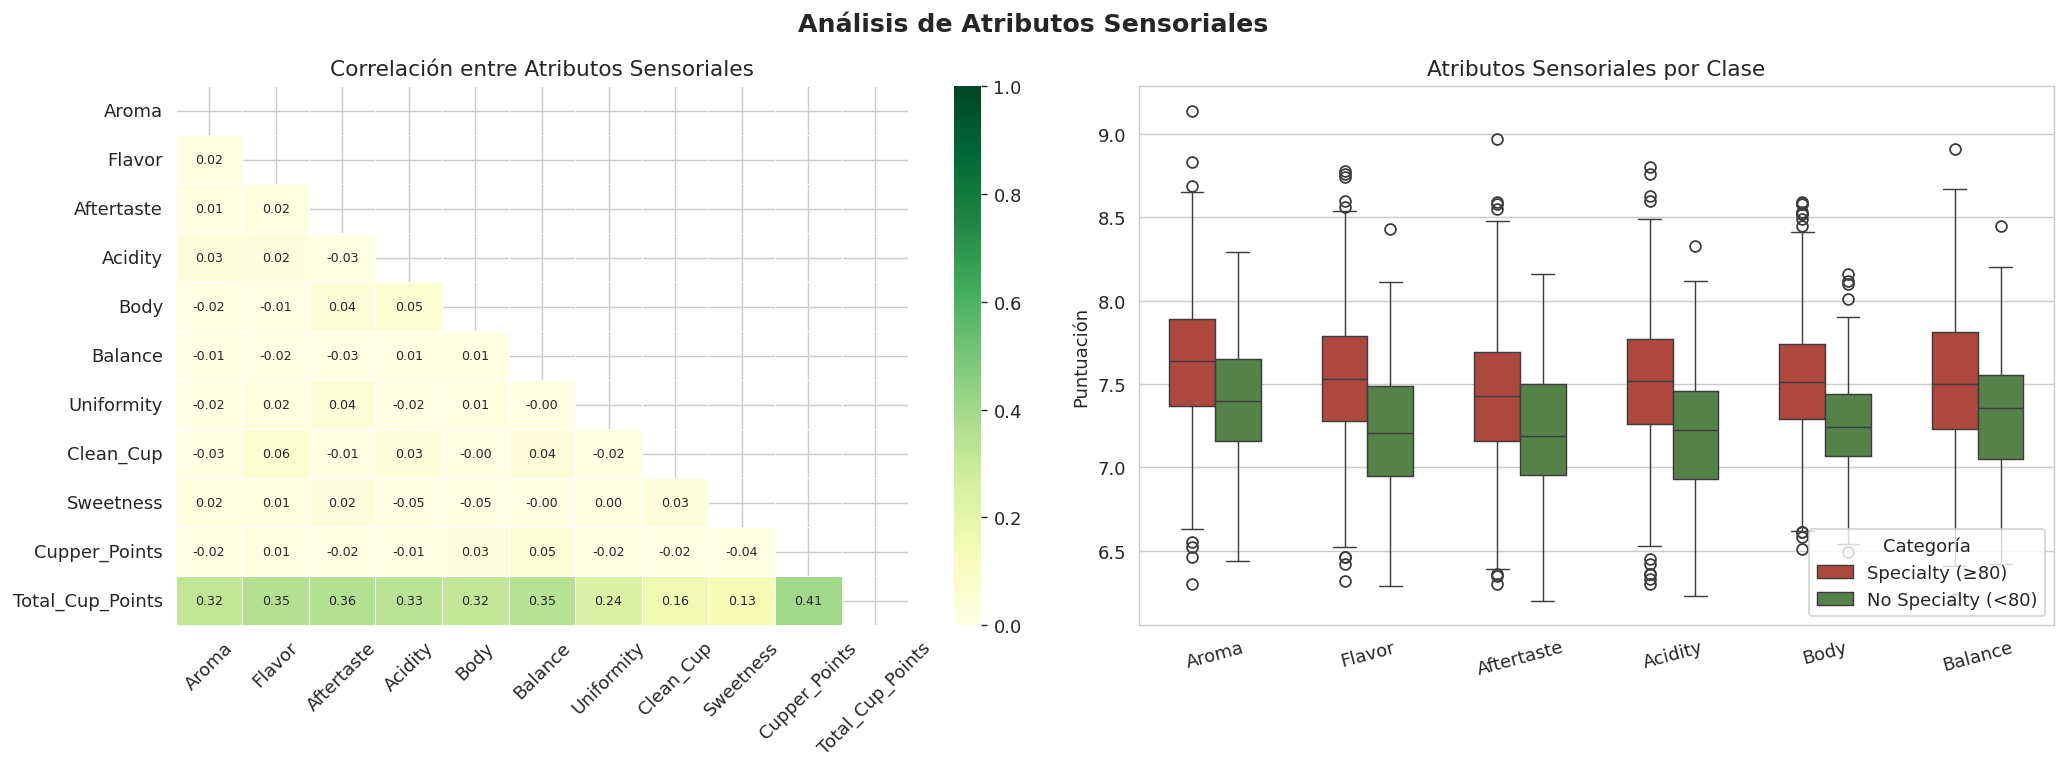

In [23]:
# ---------- FIGURA 2: Correlaciones y atributos sensoriales ----------
sensory_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
                'Balance', 'Uniformity', 'Clean_Cup', 'Sweetness',
                'Cupper_Points', 'Total_Cup_Points']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Atributos Sensoriales', fontsize=14, fontweight='bold')

# Mapa de calor de correlaciones
corr = df[sensory_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='YlGn',
            ax=axes[0], linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size': 7})
axes[0].set_title('Correlación entre Atributos Sensoriales')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de atributos por clase
attrs = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
df_melt = df[attrs + ['Quality_Label']].melt(id_vars='Quality_Label',
                                              var_name='Atributo', value_name='Puntuación')
sns.boxplot(data=df_melt, x='Atributo', y='Puntuación', hue='Quality_Label',
            palette=PALETTE[::-1], ax=axes[1], width=0.6, linewidth=0.8)
axes[1].set_title('Atributos Sensoriales por Clase')
axes[1].legend(title='Categoría', loc='lower right')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig2_correlaciones.png', bbox_inches='tight')
plt.show()

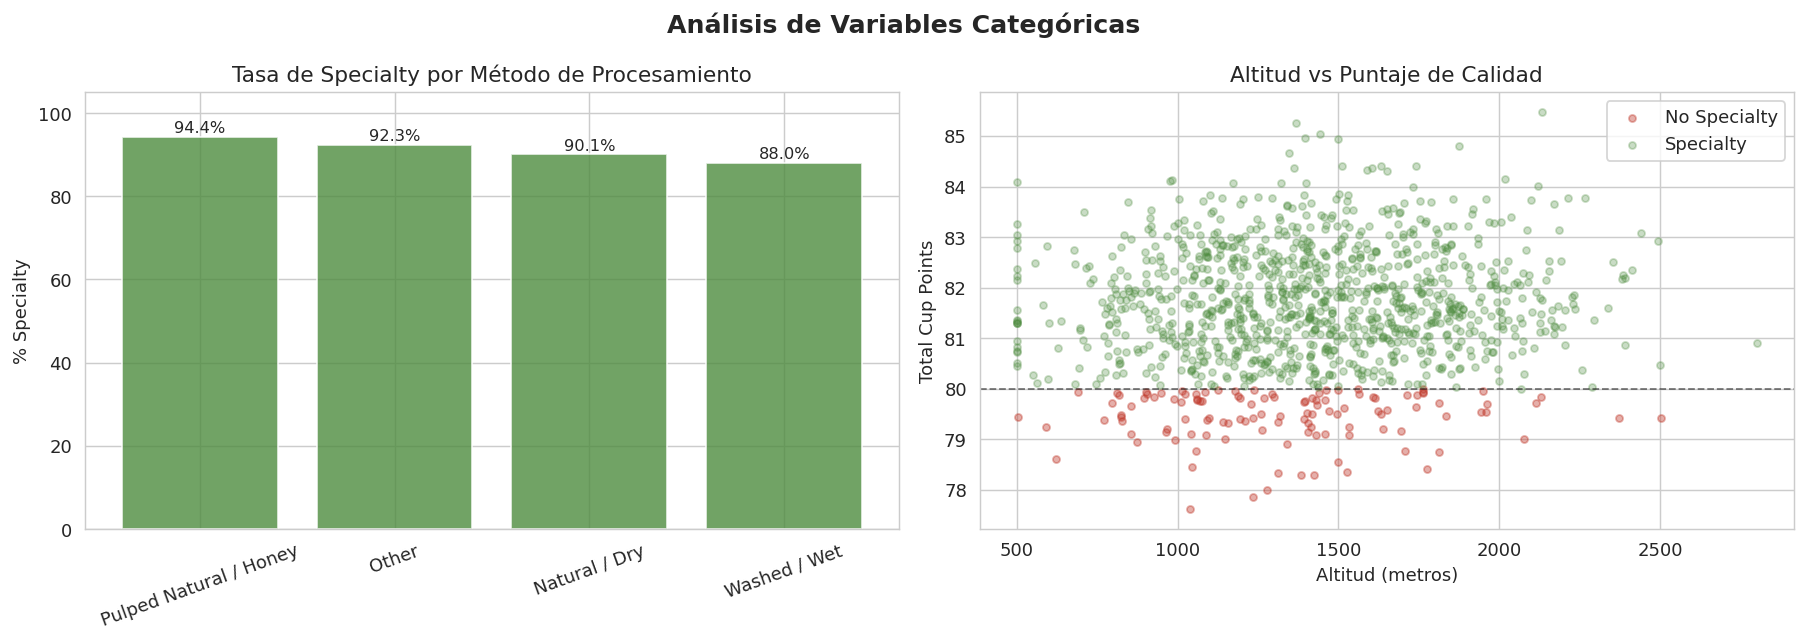

In [24]:
# ---------- FIGURA 3: Variables categóricas ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Variables Categóricas', fontsize=14, fontweight='bold')

# Tasa de specialty por método de procesamiento
proc_rate = df.groupby('Processing_Method')['Quality'].mean().sort_values(ascending=False)
bars = axes[0].bar(proc_rate.index, proc_rate.values * 100,
                   color='#4e8c3f', alpha=0.8, edgecolor='white')
axes[0].set_ylabel('% Specialty')
axes[0].set_title('Tasa de Specialty por Método de Procesamiento')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, proc_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=9)

# Altitud vs puntaje
axes[1].scatter(df[df['Quality']==0]['Altitude_mean_meters'],
                df[df['Quality']==0]['Total_Cup_Points'],
                c=PALETTE[1], alpha=0.4, s=15, label='No Specialty')
axes[1].scatter(df[df['Quality']==1]['Altitude_mean_meters'],
                df[df['Quality']==1]['Total_Cup_Points'],
                c=PALETTE[0], alpha=0.3, s=15, label='Specialty')
axes[1].set_xlabel('Altitud (metros)')
axes[1].set_ylabel('Total Cup Points')
axes[1].set_title('Altitud vs Puntaje de Calidad')
axes[1].axhline(80, color='black', linestyle='--', lw=1, alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_categoricas.png', bbox_inches='tight')
plt.show()

## 2. Preprocesamiento

In [25]:
# =============================================================================
print("\n" + "=" * 60)
print("2. PREPROCESAMIENTO")
print("=" * 60)

# Features y target
feature_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
                'Uniformity', 'Clean_Cup', 'Sweetness', 'Cupper_Points',
                'Moisture', 'Category_One_Defects', 'Category_Two_Defects',
                'Altitude_mean_meters', 'Processing_Method', 'Color', 'Variety']

X = df[feature_cols].copy()
y = df['Quality']

# Codificación de variables categóricas
cat_cols = ['Processing_Method', 'Color', 'Variety']
num_cols = [c for c in feature_cols if c not in cat_cols]

# Imputación: numérico → mediana, categórico → moda
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Label encoding para categóricas
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print(f"Features usados: {len(feature_cols)}")
print(f"Nulos restantes: {X.isnull().sum().sum()}")

# División train / test (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nConjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba:        {X_test.shape[0]} muestras")

# Escalado (solo para Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


2. PREPROCESAMIENTO
Features usados: 17
Nulos restantes: 0

Conjunto de entrenamiento: 960 muestras
Conjunto de prueba:        240 muestras


## 3. Entrenamiento de Modelos

In [26]:
# =============================================================================
print("\n" + "=" * 60)
print("3. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS")
print("=" * 60)

# --- Modelo 1: Regresión Logística (baseline) ---
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_cv = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='f1')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
print(f"\n[1] Regresión Logística")
print(f"    CV F1 (mean ± std): {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"    Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"    Test F1:       {f1_score(y_test, y_pred_lr):.4f}")
print(f"    Test AUC-ROC:  {roc_auc_score(y_test, y_prob_lr):.4f}")


3. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS

[1] Regresión Logística
    CV F1 (mean ± std): 0.9641 ± 0.0123
    Test Accuracy: 0.9208
    Test F1:       0.9542
    Test AUC-ROC:  0.9888


In [27]:
# --- Modelo 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42,
                            class_weight='balanced', n_jobs=-1)
rf_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f"\n[2] Random Forest")
print(f"    CV F1 (mean ± std): {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"    Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"    Test F1:       {f1_score(y_test, y_pred_rf):.4f}")
print(f"    Test AUC-ROC:  {roc_auc_score(y_test, y_prob_rf):.4f}")


[2] Random Forest
    CV F1 (mean ± std): 0.9514 ± 0.0032
    Test Accuracy: 0.9125
    Test F1:       0.9536
    Test AUC-ROC:  0.9657


In [28]:
# --- Modelo 3: XGBoost ---
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, n_jobs=-1
)
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(f"\n[3] XGBoost")
print(f"    CV F1 (mean ± std): {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print(f"    Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"    Test F1:       {f1_score(y_test, y_pred_xgb):.4f}")
print(f"    Test AUC-ROC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")


[3] XGBoost
    CV F1 (mean ± std): 0.9489 ± 0.0131
    Test Accuracy: 0.9125
    Test F1:       0.9508
    Test AUC-ROC:  0.9221


## 3b. Modelo Adicional: PCA + Regresión Logística


3b. MODELO ADICIONAL: PCA + REGRESIÓN LOGÍSTICA

Componentes PCA retenidos: 16 (de 17 features originales)
Varianza explicada:        95.48%

CV F1 (mean ± std): 0.9597 ± 0.0137
Test Accuracy: 0.9250
Test F1:       0.9569
Test AUC-ROC:  0.9904


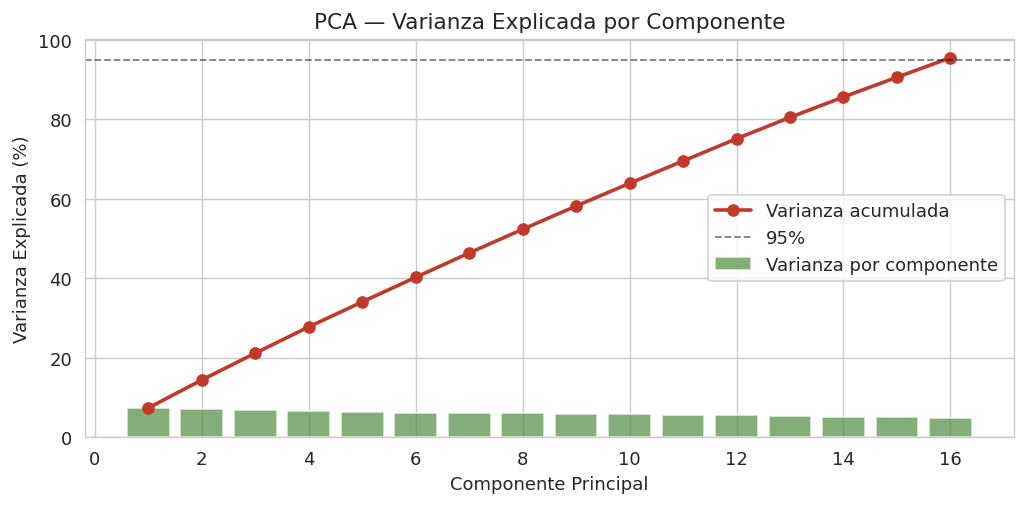


✓ Figura PCA guardada


In [29]:
# =============================================================================
# PCA + REGRESIÓN LOGÍSTICA
# Justificación: varias variables sensoriales están correlacionadas entre sí
# (visto en Figura 2). PCA las resume en componentes independientes antes de
# entrenar la Regresión Logística, lo que puede mejorar su rendimiento.
# =============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

print("\n" + "=" * 60)
print("3b. MODELO ADICIONAL: PCA + REGRESIÓN LOGÍSTICA")
print("=" * 60)

# Pipeline: escalado → PCA → Logístico
# n_components=0.95 retiene el 95% de la varianza explicada
pca_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Validación cruzada
pca_lr_cv = cross_val_score(pca_lr_pipeline, X_train, y_train, cv=cv, scoring='f1')

# Entrenamiento final
pca_lr_pipeline.fit(X_train, y_train)
y_pred_pca = pca_lr_pipeline.predict(X_test)
y_prob_pca = pca_lr_pipeline.predict_proba(X_test)[:, 1]

# Cuántos componentes retuvo PCA
n_components = pca_lr_pipeline.named_steps['pca'].n_components_
var_explained = pca_lr_pipeline.named_steps['pca'].explained_variance_ratio_.sum()

print(f"\nComponentes PCA retenidos: {n_components} (de {X_train.shape[1]} features originales)")
print(f"Varianza explicada:        {var_explained:.2%}")
print(f"\nCV F1 (mean ± std): {pca_lr_cv.mean():.4f} ± {pca_lr_cv.std():.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")
print(f"Test F1:       {f1_score(y_test, y_pred_pca):.4f}")
print(f"Test AUC-ROC:  {roc_auc_score(y_test, y_prob_pca):.4f}")

# Varianza acumulada por componente
pca_step = pca_lr_pipeline.named_steps['pca']
cumvar = pca_step.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar)+1), pca_step.explained_variance_ratio_ * 100,
       color='#4e8c3f', alpha=0.7, label='Varianza por componente')
ax.plot(range(1, len(cumvar)+1), cumvar * 100, 'o-',
        color='#c0392b', lw=2, label='Varianza acumulada')
ax.axhline(95, color='black', linestyle='--', lw=1, alpha=0.5, label='95%')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Explicada (%)')
ax.set_title('PCA — Varianza Explicada por Componente')
ax.legend()
plt.tight_layout()
plt.savefig('fig_pca.png', bbox_inches='tight')
plt.show()
print("\n✓ Figura PCA guardada")


## 4. Optimización de Hiperparámetros (todos los modelos)

In [30]:
# =============================================================================
print("\n" + "=" * 60)
print("4. OPTIMIZACIÓN DE HIPERPARÁMETROS (todos los modelos)")
print("=" * 60)

# --- 4.1 Regresión Logística ---
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    param_grid_lr, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_sc, y_train)
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_sc)
y_prob_best_lr = best_lr.predict_proba(X_test_sc)[:, 1]
print(f"\n[1] Regresión Logística Optimizada")
print(f"    Mejores params: {grid_lr.best_params_}")
print(f"    Mejor CV F1:   {grid_lr.best_score_:.4f}")
print(f"    Test Accuracy: {accuracy_score(y_test, y_pred_best_lr):.4f}")
print(f"    Test F1:       {f1_score(y_test, y_pred_best_lr):.4f}")
print(f"    Test AUC-ROC:  {roc_auc_score(y_test, y_prob_best_lr):.4f}")

# --- 4.2 Random Forest ---
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]
print(f"\n[2] Random Forest Optimizado")
print(f"    Mejores params: {grid_rf.best_params_}")
print(f"    Mejor CV F1:   {grid_rf.best_score_:.4f}")
print(f"    Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"    Test F1:       {f1_score(y_test, y_pred_best):.4f}")
print(f"    Test AUC-ROC:  {roc_auc_score(y_test, y_prob_best):.4f}")

# --- 4.3 XGBoost ---
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 6],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(
    xgb.XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, n_jobs=-1
    ),
    param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
print(f"\n[3] XGBoost Optimizado")
print(f"    Mejores params: {grid_xgb.best_params_}")
print(f"    Mejor CV F1:   {grid_xgb.best_score_:.4f}")
print(f"    Test Accuracy: {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print(f"    Test F1:       {f1_score(y_test, y_pred_best_xgb):.4f}")
print(f"    Test AUC-ROC:  {roc_auc_score(y_test, y_prob_best_xgb):.4f}")

print("\nReporte de clasificación (RF Optimizado):")
print(classification_report(y_test, y_pred_best, target_names=['No Specialty', 'Specialty']))



4. OPTIMIZACIÓN DE HIPERPARÁMETROS (todos los modelos)


0.03s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0


[1] Regresión Logística Optimizada
    Mejores params: {'C': 10, 'max_iter': 500, 'solver': 'liblinear'}
    Mejor CV F1:   0.9679
    Test Accuracy: 0.9250
    Test F1:       0.9569
    Test AUC-ROC:  0.9892

[2] Random Forest Optimizado
    Mejores params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
    Mejor CV F1:   0.9551
    Test Accuracy: 0.9250
    Test F1:       0.9600
    Test AUC-ROC:  0.9597

[3] XGBoost Optimizado
    Mejores params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
    Mejor CV F1:   0.9578
    Test Accuracy: 0.9333
    Test F1:       0.9628
    Test AUC-ROC:  0.9479

Reporte de clasificación (RF Optimizado):
              precision    recall  f1-score   support

No Specialty       1.00      0.25      0.40        24
   Specialty       0.92      1.00      0.96       216

    accuracy                           0.93       240
   macro avg       0.96      0.62      0.68       240
weighted

## 5. Visualización de Resultados


5. VISUALIZACIÓN DE RESULTADOS


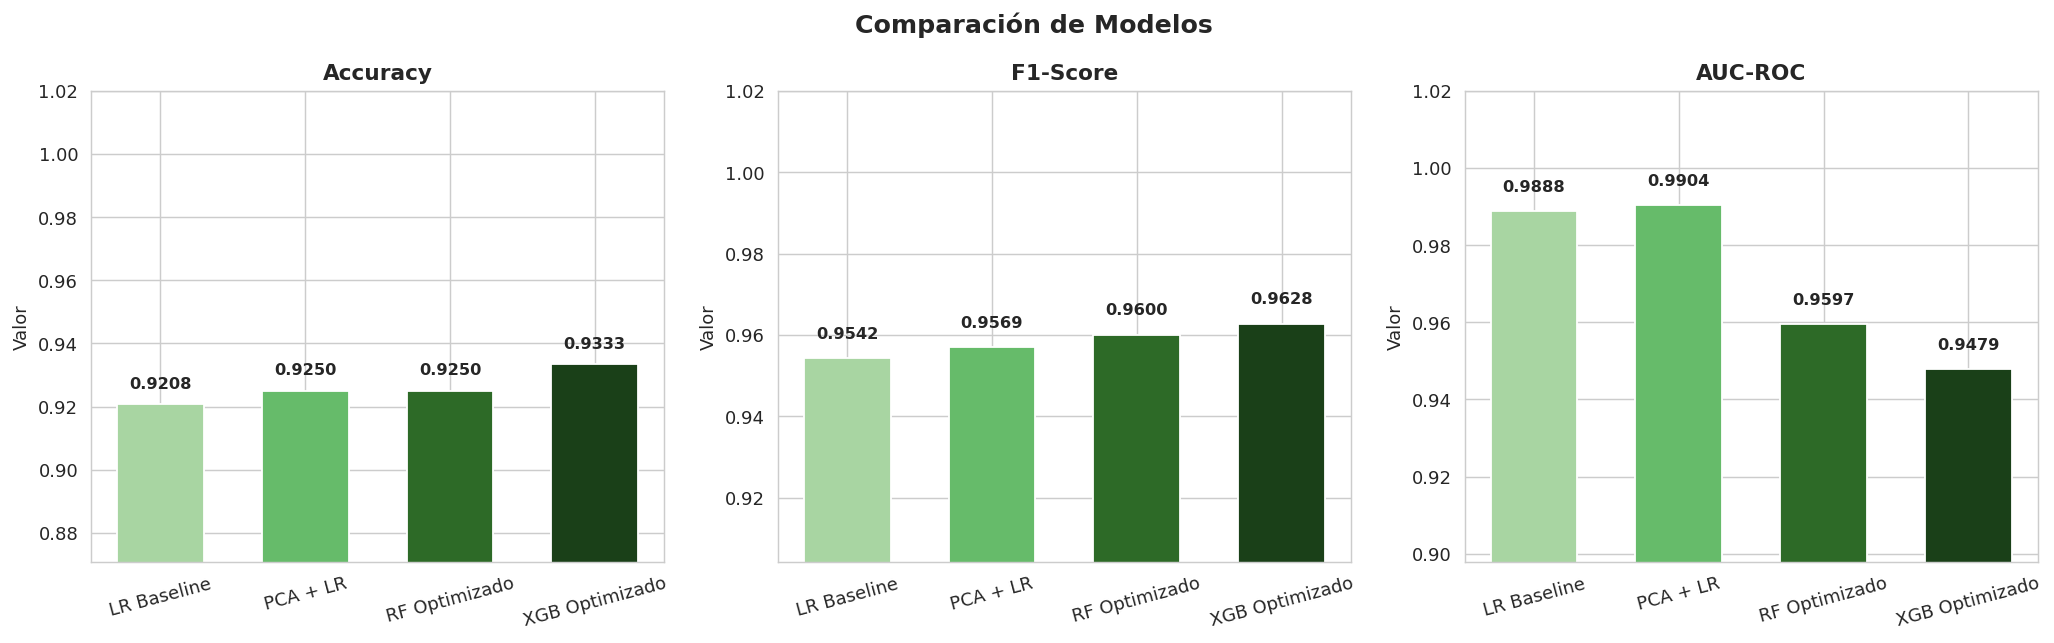

In [31]:
# =============================================================================
print("\n" + "=" * 60)
print("5. VISUALIZACIÓN DE RESULTADOS")
print("=" * 60)

models_info = {
    'LR Baseline':    (y_pred_lr, y_prob_lr),
    'PCA + LR':       (y_pred_pca, y_prob_pca),
    'RF Optimizado':  (y_pred_best, y_prob_best),
    'XGB Optimizado': (y_pred_best_xgb, y_prob_best_xgb),
}

# ---------- FIGURA 4: Comparación de métricas ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')

names = list(models_info.keys())
accs  = [accuracy_score(y_test, p) for p, _ in models_info.values()]
f1s   = [f1_score(y_test, p) for p, _ in models_info.values()]
aucs  = [roc_auc_score(y_test, pb) for _, pb in models_info.values()]

colors_bar = ['#a8d5a2', '#66bb6a', '#2d6a27', '#1a4018']

for ax, metric, values, title in zip(
        axes,
        [accs, f1s, aucs],
        [accs, f1s, aucs],
        ['Accuracy', 'F1-Score', 'AUC-ROC']):
    bars = ax.bar(names, values, color=colors_bar, edgecolor='white', width=0.6)
    ax.set_ylim(min(values) - 0.05, 1.02)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylabel('Valor')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_comparacion.png', bbox_inches='tight')
plt.show()

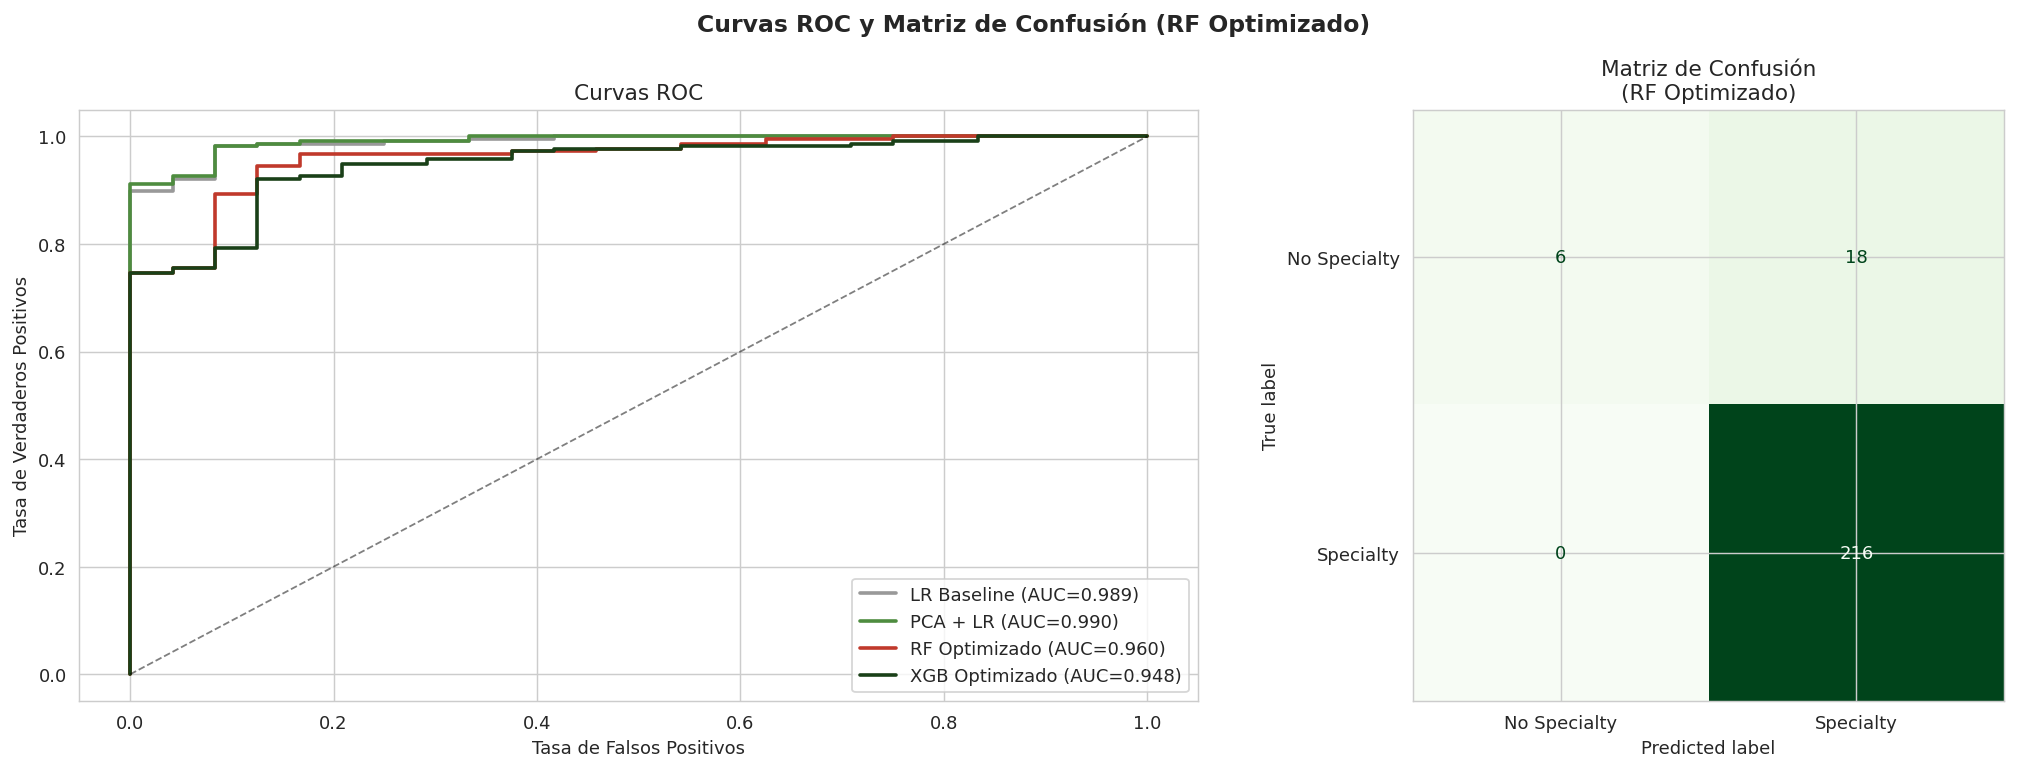

In [32]:
# ---------- FIGURA 5: Curvas ROC + Matrices de confusión ----------
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 5, figure=fig)
fig.suptitle('Curvas ROC y Matriz de Confusión (RF Optimizado)', fontsize=13, fontweight='bold')

# Curvas ROC
ax_roc = fig.add_subplot(gs[0, :3])
plot_colors = ['#999999', '#4e8c3f', '#c0392b', '#1a4018']
for (name, (_, prob)), col in zip(models_info.items(), plot_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=col, lw=2)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax_roc.set_xlabel('Tasa de Falsos Positivos')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos')
ax_roc.set_title('Curvas ROC')
ax_roc.legend(loc='lower right')

# Matriz de confusión RF optimizado
ax_cm = fig.add_subplot(gs[0, 3:])
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Specialty', 'Specialty'])
disp.plot(ax=ax_cm, colorbar=False, cmap='Greens')
ax_cm.set_title('Matriz de Confusión\n(RF Optimizado)')

plt.tight_layout()
plt.savefig('fig5_roc_cm.png', bbox_inches='tight')
plt.show()

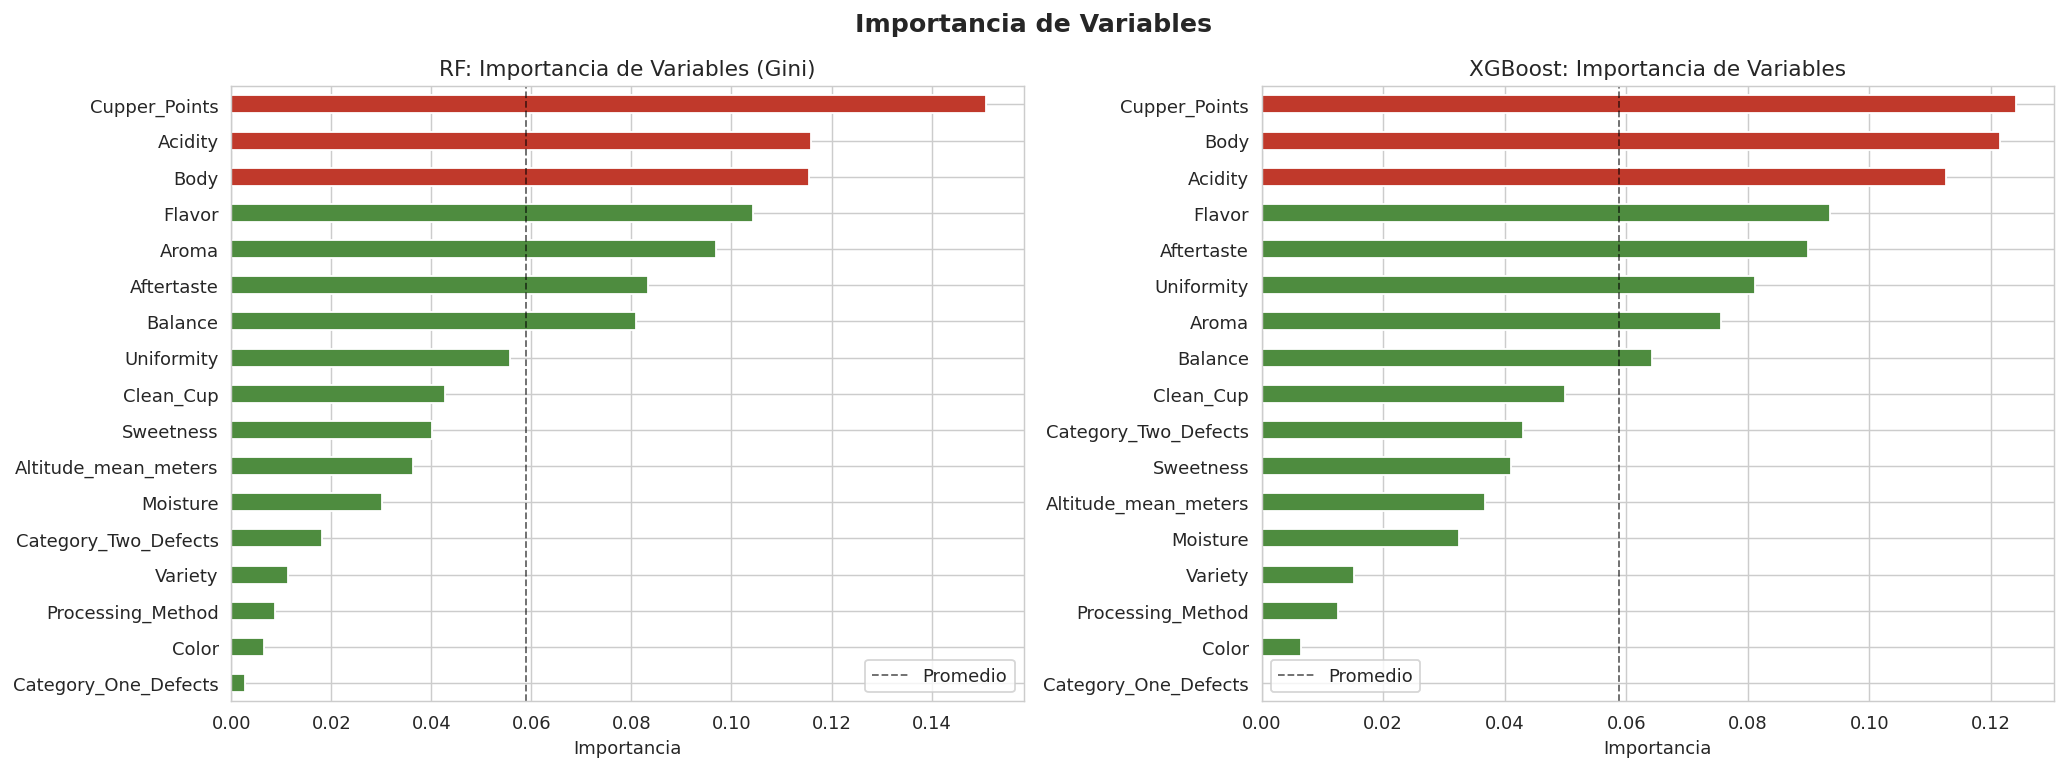

In [33]:
# ---------- FIGURA 6: Importancia de variables ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importancia de Variables', fontsize=14, fontweight='bold')

# Random Forest feature importance
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()
colors_imp = ['#c0392b' if i >= len(importances) - 3 else '#4e8c3f'
              for i in range(len(importances))]
importances.plot(kind='barh', ax=axes[0], color=colors_imp, edgecolor='white')
axes[0].set_title('RF: Importancia de Variables (Gini)')
axes[0].set_xlabel('Importancia')
axes[0].axvline(importances.mean(), color='black', linestyle='--',
                lw=1, alpha=0.6, label='Promedio')
axes[0].legend()

# XGBoost feature importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
colors_xgb = ['#c0392b' if i >= len(xgb_imp) - 3 else '#4e8c3f'
               for i in range(len(xgb_imp))]
xgb_imp.plot(kind='barh', ax=axes[1], color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost: Importancia de Variables')
axes[1].set_xlabel('Importancia')
axes[1].axvline(xgb_imp.mean(), color='black', linestyle='--',
                lw=1, alpha=0.6, label='Promedio')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_importancia.png', bbox_inches='tight')
plt.show()

## 6. Resumen Final

In [34]:
# =============================================================================
print("\n" + "=" * 60)
print("6. RESUMEN FINAL DE RESULTADOS")
print("=" * 60)

results_df = pd.DataFrame({
    'Modelo': names,
    'Accuracy': [f'{v:.4f}' for v in accs],
    'F1-Score': [f'{v:.4f}' for v in f1s],
    'AUC-ROC':  [f'{v:.4f}' for v in aucs],
})
print(results_df.to_string(index=False))

top3 = pd.Series(best_rf.feature_importances_, index=feature_cols).nlargest(3)
print(f"\nTop 3 variables más importantes (RF Optimizado):")
for feat, val in top3.items():
    print(f"  {feat}: {val:.4f}")



6. RESUMEN FINAL DE RESULTADOS
        Modelo Accuracy F1-Score AUC-ROC
   LR Baseline   0.9208   0.9542  0.9888
      PCA + LR   0.9250   0.9569  0.9904
 RF Optimizado   0.9250   0.9600  0.9597
XGB Optimizado   0.9333   0.9628  0.9479

Top 3 variables más importantes (RF Optimizado):
  Cupper_Points: 0.1509
  Acidity: 0.1159
  Body: 0.1155


## 7. Conclusiones, Limitaciones y Aplicación Real

---

### 7.1 Conclusiones principales

| Modelo | Accuracy | F1-Score | AUC-ROC |
|--------|----------|----------|---------|
| LR Baseline | 0.9208 | 0.9542 | 0.9888 |
| PCA + LR | 0.9250 | 0.9569 | **0.9904** |
| RF Optimizado | 0.9250 | 0.9600 | 0.9597 |
| **XGB Optimizado** | **0.9333** | **0.9628** | 0.9479 |

- El **XGBoost Optimizado** fue el mejor modelo con F1 = 0.9628 y Accuracy = 0.9333, seleccionado como modelo definitivo.
- **PCA + Logistic Regression** obtuvo el mayor AUC-ROC (0.9904), lo que indica que reducir la dimensionalidad mejora la capacidad discriminativa del modelo lineal.
- Las **3 variables más importantes** para predecir calidad son: `Cupper_Points` (0.1509), `Acidity` (0.1159) y `Body` (0.1155) — los pilares de la evaluación sensorial profesional.
- El método de procesamiento **Washed/Wet** y altitudes **superiores a 1,400 m** están asociados con mayores tasas de cafés Specialty.

---

### 7.2 Limitaciones

- **Desbalance de clases (89.8% Specialty / 10.2% No Specialty):** el modelo tiene un recall bajo para "No Specialty", dejando pasar cafés de baja calidad como buenos. En un contexto de exportación esto tiene implicaciones económicas reales.
- **Label Encoding** en variables categóricas introduce un orden implícito que puede no ser apropiado.
- No se exploraron técnicas de balanceo como **SMOTE** ni ajuste del umbral de decisión.

---

### 7.3 Mejoras propuestas

- Aplicar **SMOTE** para sobremuestrear la clase minoritaria y mejorar el recall de "No Specialty".
- Ajustar el **umbral de decisión** (actualmente 0.5) para optimizar el balance precisión-recall según el caso de uso.
- Reemplazar Label Encoding por **One-Hot Encoding** en variables como `Processing_Method` y `Color`.
- Validar el modelo con el **dataset real** del CQI disponible en Kaggle.

---

### 7.4 Propuesta de aplicación en escenario real

Este modelo podría integrarse como herramienta de apoyo en **cooperativas cafeteras del Eje Cafetero, Huila o Nariño** para hacer una pre-clasificación automatizada de lotes *antes* de la catación formal.

**Flujo propuesto:**
1. Se registran los atributos del lote (aroma, acidez, cuerpo, método de beneficio, altitud)
2. El modelo predice si el lote es candidato a Specialty
3. Solo los lotes con alta probabilidad pasan a la catación humana detallada

**Beneficio:** reduce el tiempo y costo del proceso de certificación, priorizando los lotes con mayor potencial comercial.
